# Results Summary - Automatic Image Captioning

Team: Nebojsa Vuga, Bogdan Janosevic  
Random seed: `3`

This notebook summarizes evaluation results for:
- CNN + LSTM
- ViT + GPT2 (`num_beams=4`)
- CLIP Retrieval (ViT-B/32)
- CLIP Retrieval (RN50)

Evaluated on dataset sizes: `3k`, `15k`, `25k`.

## 1. Load Results

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

results = [
    {
        "model": "CNN+LSTM",
        "images (k)": 3,
        "bleu": 0.0833,
        "rouge1_f": 0.26383696474455914,
        "rouge2_f": 0.07168919809864721,
        "rougel_f": 0.22834864502928964,
        "meteor": 0.2830,
        "notes": "epochs=2"
    },
    {
        "model": "CNN+LSTM",
        "images (k)": 15,
        "bleu": 0.1359,
        "rouge1_f": 0.2510641666372084,
        "rouge2_f": 0.07474446218225134,
        "rougel_f": 0.23227107839548722,
        "meteor": 0.3001,
        "notes": "epochs=6"
    },
    {
        "model": "CNN+LSTM",
        "images (k)": 25,
        "bleu": 0.1069,
        "rouge1_f": 0.25430729831934323,
        "rouge2_f": 0.07832242626549259,
        "rougel_f": 0.22354574755919868,
        "meteor": 0.2807,
        "notes": "epochs=8"
    },

    {
        "model": "ViT+GPT2 (beam=4)",
        "images (k)": 3,
        "bleu": 0.1816,
        "rouge1_f": 0.278053499173882,
        "rouge2_f": 0.08837743143862144,
        "rougel_f": 0.25583891067420045,
        "meteor": 0.3683,
        "notes": "-"
    },
    {
        "model": "ViT+GPT2 (beam=4)",
        "images (k)": 15,
        "bleu": 0.1777,
        "rouge1_f": 0.2844710675690878,
        "rouge2_f": 0.0875580940261852,
        "rougel_f": 0.2573861378263678,
        "meteor": 0.3728,
        "notes": "-"
    },
    {
        "model": "ViT+GPT2 (beam=4)",
        "images (k)": 25,
        "bleu": 0.1776,
        "rouge1_f": 0.2799533359642913,
        "rouge2_f": 0.08268114530553089,
        "rougel_f": 0.25239957019794296,
        "meteor": 0.3652,
        "notes": "-"
    },

    {
        "model": "CLIP Retrieval ViT-B/32",
        "images (k)": 3,
        "bleu": 0.0662,
        "rouge1_f": 0.2394900765458928,
        "rouge2_f": 0.05376797418491134,
        "rougel_f": 0.19775341439880664,
        "meteor": 0.3149,
        "notes": "-"
    },
    {
        "model": "CLIP Retrieval ViT-B/32",
        "images (k)": 15,
        "bleu": 0.0766,
        "rouge1_f": 0.2587462787146606,
        "rouge2_f": 0.06199927144128299,
        "rougel_f": 0.21755556231308082,
        "meteor": 0.3389,
        "notes": "-"
    },
    {
        "model": "CLIP Retrieval ViT-B/32",
        "images (k)": 25,
        "bleu": 0.0770,
        "rouge1_f": 0.25984944704107715,
        "rouge2_f": 0.06121173223406856,
        "rougel_f": 0.21543298526530294,
        "meteor": 0.3397,
        "notes": "-"
    },

    {
        "model": "CLIP Retrieval RN50",
        "images (k)": 3,
        "bleu": 0.0723,
        "rouge1_f": 0.23946086537632744,
        "rouge2_f": 0.05890232930112646,
        "rougel_f": 0.20319393595278848,
        "meteor": 0.3077,
        "notes": "-"
    },
    {
        "model": "CLIP Retrieval RN50",
        "images (k)": 15,
        "bleu": 0.0739,
        "rouge1_f": 0.26057986654045573,
        "rouge2_f": 0.06340766741605529,
        "rougel_f": 0.21960973873146394,
        "meteor": 0.3416,
        "notes": "-"
    },
    {
        "model": "CLIP Retrieval RN50",
        "images (k)": 25,
        "bleu": 0.0794,
        "rouge1_f": 0.2633620697043904,
        "rouge2_f": 0.06436402488834451,
        "rougel_f": 0.22033091896853163,
        "meteor": 0.3408,
        "notes": "-"
    },
]

df = pd.DataFrame(results)
df = df.sort_values(["images (k)", "model"]).reset_index(drop=True)
df

,model,images (k),bleu,rouge1_f,rouge2_f,rougel_f,meteor,notes
0,CLIP Retrieval RN50,3,0.0723,0.239461,0.058902,0.203194,0.3077,-
1,CLIP Retrieval ViT-B/32,3,0.0662,0.239490,0.053768,0.197753,0.3149,-
2,CNN+LSTM,3,0.0833,0.263837,0.071689,0.228349,0.2830,epochs=2
3,ViT+GPT2 (beam=4),3,0.1816,0.278053,0.088377,0.255839,0.3683,-
4,CLIP Retrieval RN50,15,0.0739,0.260580,0.063408,0.219610,0.3416,-
5,CLIP Retrieval ViT-B/32,15,0.0766,0.258746,0.061999,0.217556,0.3389,-
6,CNN+LSTM,15,0.1359,0.251064,0.074744,0.232271,0.3001,epochs=6
7,ViT+GPT2 (beam=4),15,0.1777,0.284471,0.087558,0.257386,0.3728,-
8,CLIP Retrieval RN50,25,0.0794,0.263362,0.064364,0.220331,0.3408,-
9,CLIP Retrieval ViT-B/32,25,0.0770,0.259849,0.061212,0.215433,0.3397,-


## 2. Metrics Tables

In [29]:
for size in [3, 15, 25]:
    print(f"\n=== Dataset size: {size}k ===")
    display(
        df[df["images (k)"] == size][
            ["model", "bleu", "rouge1_f", "rouge2_f", "rougel_f", "meteor", "notes"]
        ].sort_values("meteor", ascending=False)
    )


=== Dataset size: 3k ===


,model,bleu,rouge1_f,rouge2_f,rougel_f,meteor,notes
3,ViT+GPT2 (beam=4),0.1816,0.278053,0.088377,0.255839,0.3683,-
1,CLIP Retrieval ViT-B/32,0.0662,0.239490,0.053768,0.197753,0.3149,-
0,CLIP Retrieval RN50,0.0723,0.239461,0.058902,0.203194,0.3077,-
2,CNN+LSTM,0.0833,0.263837,0.071689,0.228349,0.2830,epochs=2



=== Dataset size: 15k ===


,model,bleu,rouge1_f,rouge2_f,rougel_f,meteor,notes
7,ViT+GPT2 (beam=4),0.1777,0.284471,0.087558,0.257386,0.3728,-
4,CLIP Retrieval RN50,0.0739,0.260580,0.063408,0.219610,0.3416,-
5,CLIP Retrieval ViT-B/32,0.0766,0.258746,0.061999,0.217556,0.3389,-
6,CNN+LSTM,0.1359,0.251064,0.074744,0.232271,0.3001,epochs=6



=== Dataset size: 25k ===


,model,bleu,rouge1_f,rouge2_f,rougel_f,meteor,notes
11,ViT+GPT2 (beam=4),0.1776,0.279953,0.082681,0.252400,0.3652,-
8,CLIP Retrieval RN50,0.0794,0.263362,0.064364,0.220331,0.3408,-
9,CLIP Retrieval ViT-B/32,0.0770,0.259849,0.061212,0.215433,0.3397,-
10,CNN+LSTM,0.1069,0.254307,0.078322,0.223546,0.2807,epochs=8


## 3. Trend by Dataset Size

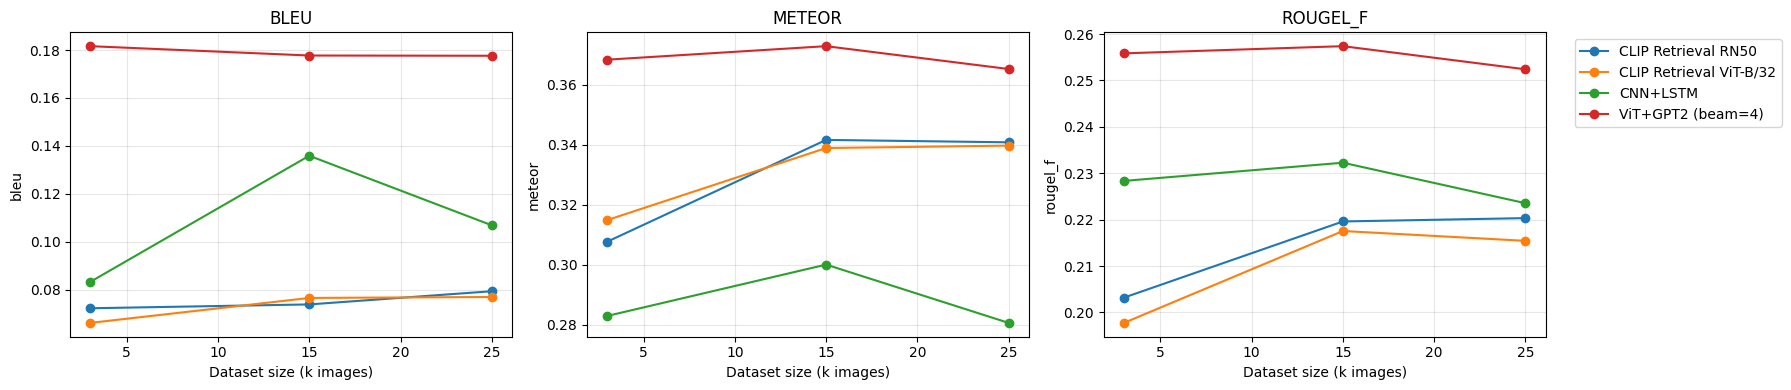

In [30]:
metrics = ["bleu", "meteor", "rougel_f"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, metric in zip(axes, metrics):
    for model in df["model"].unique():
        subset = df[df["model"] == model].sort_values("images (k)")
        ax.plot(subset["images (k)"], subset[metric], marker="o", label=model)
    ax.set_title(metric.upper())
    ax.set_xlabel("Dataset size (k images)")
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 4. Qualitative Examples (15k)

In [31]:
samples_15k = {
    "CNN+LSTM": [
        ("2744856447.jpg", "a man in a black shirt is sitting in a chair", "in a restaurant a teenager drinks directly out of the metal milkshake serving cup"),
        ("3244470342.jpg", "a man in a red wetsuit is skiing down a snowy hill", "snowboarder performing a trick high in the air over snow"),
    ],
    "ViT+GPT2 (beam=4)": [
        ("2744856447.jpg", "a man holding a cup in his hand", "in a restaurant a teenager drinks directly out of the metal milkshake serving cup"),
        ("3244470342.jpg", "a snowboarder jumping over a snow covered slope", "snowboarder performing a trick high in the air over snow"),
    ],
    "CLIP Retrieval ViT-B/32": [
        ("2744856447.jpg", "a darkhaired man in his twenties drinks a green liquid from a plastic mug", "in a restaurant a teenager drinks directly out of the metal milkshake serving cup"),
        ("3244470342.jpg", "an ice climber in a blue jacket and black pants is scaling a frozen ice wall", "snowboarder performing a trick high in the air over snow"),
    ],
    "CLIP Retrieval RN50": [
        ("2744856447.jpg", "a man handles his near empty drink while laughing at something on the other side of the table", "in a restaurant a teenager drinks directly out of the metal milkshake serving cup"),
        ("3244470342.jpg", "an ice climber in a blue jacket and black pants is scaling a frozen ice wall", "snowboarder performing a trick high in the air over snow"),
    ],
}

rows = []
for model, pairs in samples_15k.items():
    for image, pred, ref in pairs:
        rows.append({
            "model": model,
            "image": image,
            "predicted": pred,
            "reference": ref,
        })

samples_df = pd.DataFrame(rows)
samples_df

,model,image,predicted,reference
0,CNN+LSTM,2744856447.jpg,a man in a black shirt is sitting in a chair,in a restaurant a teenager drinks directly out...
1,CNN+LSTM,3244470342.jpg,a man in a red wetsuit is skiing down a snowy ...,snowboarder performing a trick high in the air...
2,ViT+GPT2 (beam=4),2744856447.jpg,a man holding a cup in his hand,in a restaurant a teenager drinks directly out...
3,ViT+GPT2 (beam=4),3244470342.jpg,a snowboarder jumping over a snow covered slope,snowboarder performing a trick high in the air...
4,CLIP Retrieval ViT-B/32,2744856447.jpg,a darkhaired man in his twenties drinks a gree...,in a restaurant a teenager drinks directly out...
5,CLIP Retrieval ViT-B/32,3244470342.jpg,an ice climber in a blue jacket and black pant...,snowboarder performing a trick high in the air...
6,CLIP Retrieval RN50,2744856447.jpg,a man handles his near empty drink while laugh...,in a restaurant a teenager drinks directly out...
7,CLIP Retrieval RN50,3244470342.jpg,an ice climber in a blue jacket and black pant...,snowboarder performing a trick high in the air...


## 5. Visual Comparison (Image + Captions)

If images do not appear, check the printed folder path and file existence.

Resolved image dir: ..\backend\images\flickr30k_images


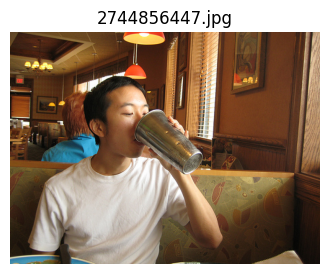

**Model:** CNN+LSTM

**Predicted:** a man in a black shirt is sitting in a chair

**Reference:** in a restaurant a teenager drinks directly out of the metal milkshake serving cup

---

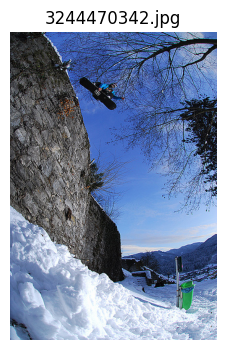

**Model:** CNN+LSTM

**Predicted:** a man in a red wetsuit is skiing down a snowy hill

**Reference:** snowboarder performing a trick high in the air over snow

---

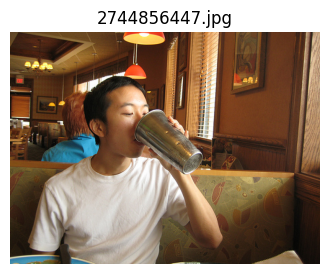

**Model:** ViT+GPT2 (beam=4)

**Predicted:** a man holding a cup in his hand

**Reference:** in a restaurant a teenager drinks directly out of the metal milkshake serving cup

---

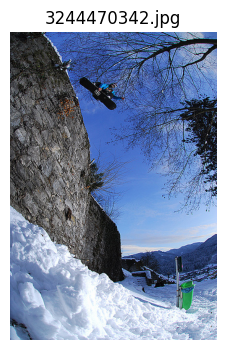

**Model:** ViT+GPT2 (beam=4)

**Predicted:** a snowboarder jumping over a snow covered slope

**Reference:** snowboarder performing a trick high in the air over snow

---

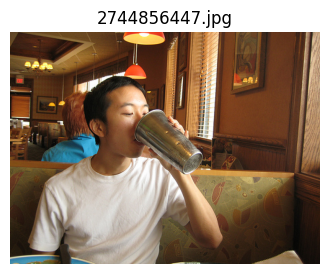

**Model:** CLIP Retrieval ViT-B/32

**Predicted:** a darkhaired man in his twenties drinks a green liquid from a plastic mug

**Reference:** in a restaurant a teenager drinks directly out of the metal milkshake serving cup

---

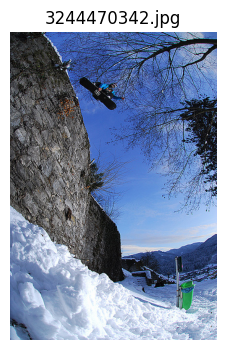

**Model:** CLIP Retrieval ViT-B/32

**Predicted:** an ice climber in a blue jacket and black pants is scaling a frozen ice wall

**Reference:** snowboarder performing a trick high in the air over snow

---

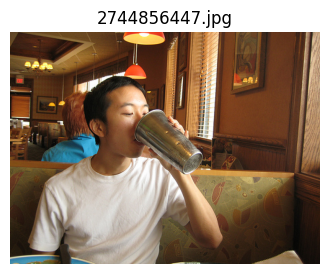

**Model:** CLIP Retrieval RN50

**Predicted:** a man handles his near empty drink while laughing at something on the other side of the table

**Reference:** in a restaurant a teenager drinks directly out of the metal milkshake serving cup

---

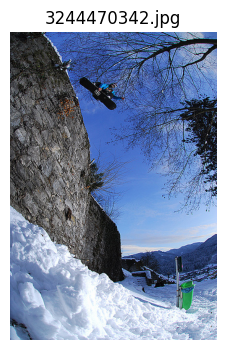

**Model:** CLIP Retrieval RN50

**Predicted:** an ice climber in a blue jacket and black pants is scaling a frozen ice wall

**Reference:** snowboarder performing a trick high in the air over snow

---

In [32]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, Markdown

candidate_dirs = [
    Path('backend/images/flickr30k_images'),
    Path('../backend/images/flickr30k_images'),
]
IMG_DIR = next((p for p in candidate_dirs if p.exists()), None)
print('Resolved image dir:', IMG_DIR)

if IMG_DIR is None:
    raise FileNotFoundError('Could not find flickr30k_images folder. Check project paths.')

def show_image_with_captions(row):
    img_path = IMG_DIR / row['image']
    if not img_path.exists():
        display(Markdown(f"**Missing image:** `{img_path}`"))
        display(Markdown('---'))
        return

    image = Image.open(img_path)
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(row['image'])
    plt.show()

    display(Markdown(f"**Model:** {row['model']}"))
    display(Markdown(f"**Predicted:** {row['predicted']}"))
    display(Markdown(f"**Reference:** {row['reference']}"))
    display(Markdown('---'))

for _, row in samples_df.head(8).iterrows():
    show_image_with_captions(row)

## 7. Final Conclusion

- Best overall metrics are from **ViT+GPT2 (beam=4)**. Beam=4 gave better results than Beam=1
- **CLIP retrieval** models are stable and improve slightly from 3k to 25k.
- **CNN+LSTM** improved from 3k to 15k, but degraded on 25k (model capacity/optimization limits).
- This is a valid and realistic result: stronger pretrained models outperform the baseline.
